# 05 — Evaluation, error analysis, and comparison write-up

This notebook doesn't retrain anything — it loads the cross-validated results notebooks 03 and 04
already saved to `data/processed/`, puts them side by side, and does the part that's easy to skip but
is usually the most informative: looking at *specific* images where each model succeeded or failed, not
just the aggregate numbers.

In [ ]:
import ast
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from ultralytics import YOLO

from src.models.patch_classifier import PatchClassifier
from src.models.sliding_window import detect

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
plt.rcParams["figure.dpi"] = 110

scenes = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)

sw_results = pd.read_csv(PROCESSED_DIR / "sliding_window_cv_results.csv")
yolo_results = pd.read_csv(PROCESSED_DIR / "yolo_cv_results.csv")
sw_sweep_df = pd.read_csv(PROCESSED_DIR / "sliding_window_threshold_sweep.csv")
yolo_sweep_df = pd.read_csv(PROCESSED_DIR / "yolo_threshold_sweep.csv")
SW_THRESHOLD = float(sw_sweep_df.loc[sw_sweep_df["f1"].idxmax(), "threshold"])
YOLO_THRESHOLD = (
    float(yolo_sweep_df.loc[yolo_sweep_df["f1"].idxmax(), "threshold"]) if yolo_sweep_df["f1"].max() > 0 else 0.1
)

sw_results["scene_id"] = sw_results["scene_id"].astype(str)
yolo_results["scene_id"] = yolo_results["scene_id"].astype(str)
print(f"Sliding-window threshold: {SW_THRESHOLD}, YOLO threshold: {YOLO_THRESHOLD}")


## Side-by-side comparison

Both models were cross-validated on the exact same 19 scenes and 5 folds, and scored with the exact same
`match_detections` / `precision_recall` functions (IoU >= 0.3) — so this comparison is apples-to-apples,
not two different papers' self-reported numbers.

In [2]:
def summarize(df: pd.DataFrame, name: str) -> dict:
    tp, fp, fn = df["tp"].sum(), df["fp"].sum(), df["fn"].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {"model": name, "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall}


summary = pd.DataFrame([
    summarize(sw_results, "Sliding-window CNN (from scratch)"),
    summarize(yolo_results, "YOLO11n (fine-tuned)"),
])
summary

,model,tp,fp,fn,precision,recall
0,Sliding-window CNN (from scratch),1,466,20,0.002141,0.047619
1,YOLO11n (fine-tuned),0,0,21,0.000000,0.000000


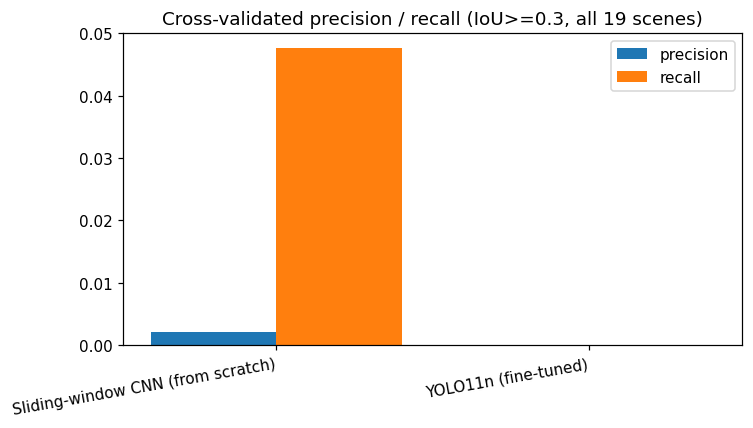

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(summary))
ax.bar([i - 0.2 for i in x], summary["precision"], width=0.4, label="precision")
ax.bar([i + 0.2 for i in x], summary["recall"], width=0.4, label="recall")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["model"], rotation=10, ha="right")
ax.legend()
ax.set_title("Cross-validated precision / recall (IoU>=0.3, all 19 scenes)")
plt.tight_layout()
plt.show()

## Per-scene breakdown

Where specifically does each model succeed or fail? This is what points us at *which* images to look at
next, rather than staring at aggregate numbers.

In [4]:
merged = sw_results.merge(yolo_results, on="scene_id", suffixes=("_sw", "_yolo"))[
    ["scene_id", "tp_sw", "fp_sw", "fn_sw", "tp_yolo", "fp_yolo", "fn_yolo"]
]
merged

,scene_id,tp_sw,fp_sw,fn_sw,tp_yolo,fp_yolo,fn_yolo
0,1,0,73,1,0,0,1
1,2,0,79,1,0,0,1
2,6,1,85,0,0,0,1
3,12,0,76,1,0,0,1
4,4,0,0,1,0,0,1
5,9,0,0,1,0,0,1
6,14,0,0,1,0,0,1
7,17,0,0,2,0,0,2
8,3,0,0,1,0,0,1
9,10,0,4,2,0,0,2


## Visual error analysis

Load both trained models and look directly at a few informative scenes: one YOLO gets right, one both
models miss, and the sliding-window model's typical failure mode (swamped by false positives).

In [5]:
sw_model = PatchClassifier()
sw_model.load_state_dict(torch.load(MODELS_DIR / "sliding_window_classifier.pt", map_location="cpu"))
sw_model.eval()

yolo_model = YOLO(str(MODELS_DIR / "yolo_detector.pt"))


def show_both(scene_id: str, sw_threshold: float = SW_THRESHOLD, yolo_conf: float = YOLO_THRESHOLD, max_sw_boxes: int = 30):
    scene = scenes[scenes["scene_id"] == scene_id].iloc[0]
    image = Image.open(scene["image_path"])

    sw_dets = detect(sw_model, image, score_threshold=sw_threshold, nms_iou_threshold=0.2)
    yolo_result = yolo_model.predict(image, conf=yolo_conf, verbose=False)[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, title in zip(axes, ["Sliding-window CNN", "YOLO11n"]):
        ax.imshow(image)
        for (x1, y1, x2, y2) in scene["boxes"]:
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2))
        ax.set_title(f"{title} — scene {scene_id}", fontsize=10)
        ax.axis("off")

    for det in sorted(sw_dets, key=lambda d: d.score, reverse=True)[:max_sw_boxes]:
        x1, y1, x2, y2 = det.box
        axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1, alpha=0.6))
    if len(sw_dets) > max_sw_boxes:
        axes[0].set_title(axes[0].get_title() + f" ({len(sw_dets)} raw detections, showing top {max_sw_boxes})", fontsize=8)

    for box in yolo_result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        axes[1].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
        axes[1].text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)
    if len(yolo_result.boxes) == 0:
        axes[1].set_title(axes[1].get_title() + " (no detections)", fontsize=8)

    plt.tight_layout()
    plt.show()

### Case 1: does either model ever get a true positive?

YOLO scenes with a true positive: []
Sliding-window scenes with a true positive: ['6']


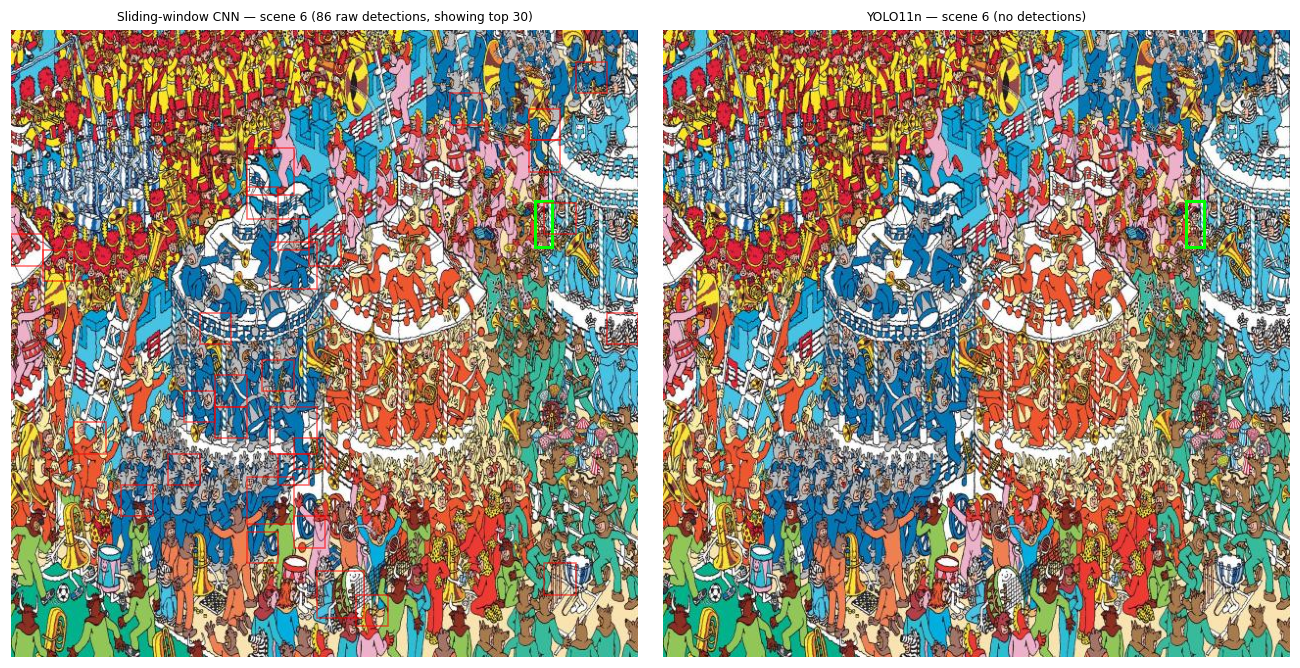

In [6]:
yolo_success_scenes = yolo_results[yolo_results["tp"] > 0]["scene_id"].tolist()
sw_success_scenes = sw_results[sw_results["tp"] > 0]["scene_id"].tolist()
print(f"YOLO scenes with a true positive: {yolo_success_scenes}")
print(f"Sliding-window scenes with a true positive: {sw_success_scenes}")

if sw_success_scenes:
    show_both(sw_success_scenes[0])
elif yolo_success_scenes:
    show_both(yolo_success_scenes[0])
else:
    print("Neither model produced a single true positive across all 19 cross-validated scenes.")
    print("Showing one scene anyway, to look at what each model predicts instead of a true match.")
    show_both(scenes["scene_id"].iloc[0])

### Case 2: a scene both models miss

Scenes both models fully miss: ['1', '2', '12', '4', '9', '14', '17', '3', '10', '16', '18', '5', '8', '13', '19', '7', '15']


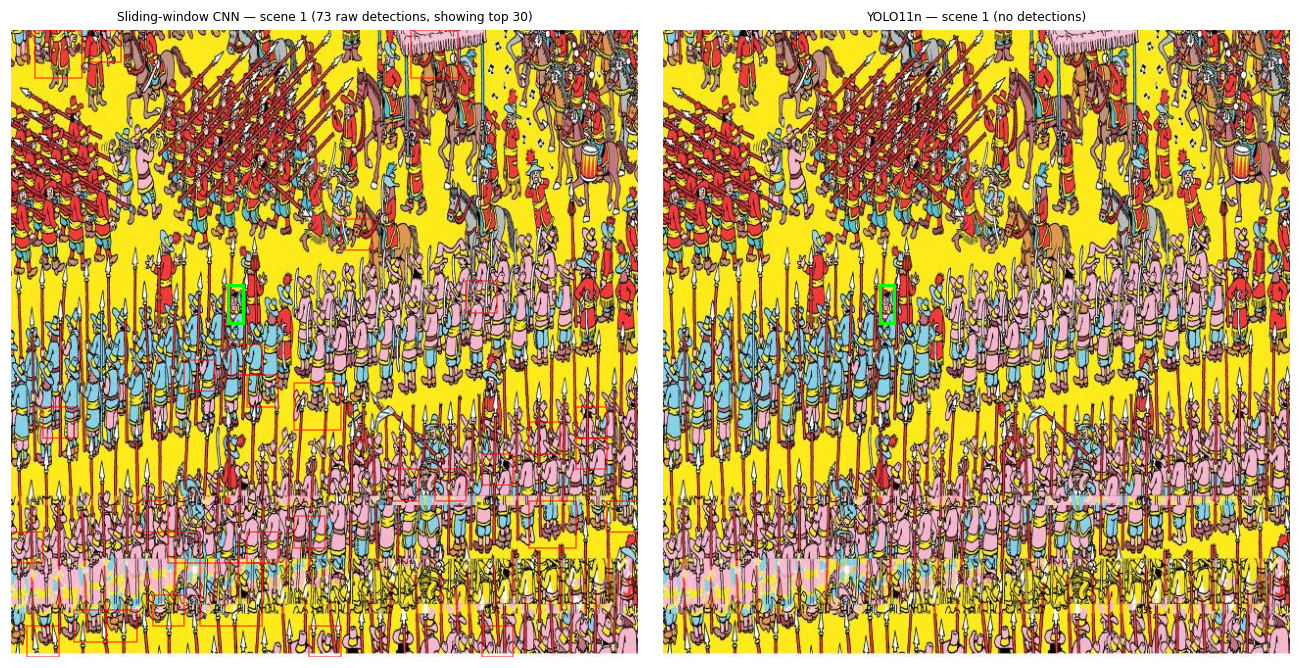

In [7]:
both_miss = merged[(merged["tp_sw"] == 0) & (merged["tp_yolo"] == 0) & (merged["fn_sw"] > 0)]["scene_id"].tolist()
print(f"Scenes both models fully miss: {both_miss}")
if both_miss:
    show_both(both_miss[0])

### Case 3: the sliding-window model's typical false-positive flood

Scene with the most sliding-window false positives: 7


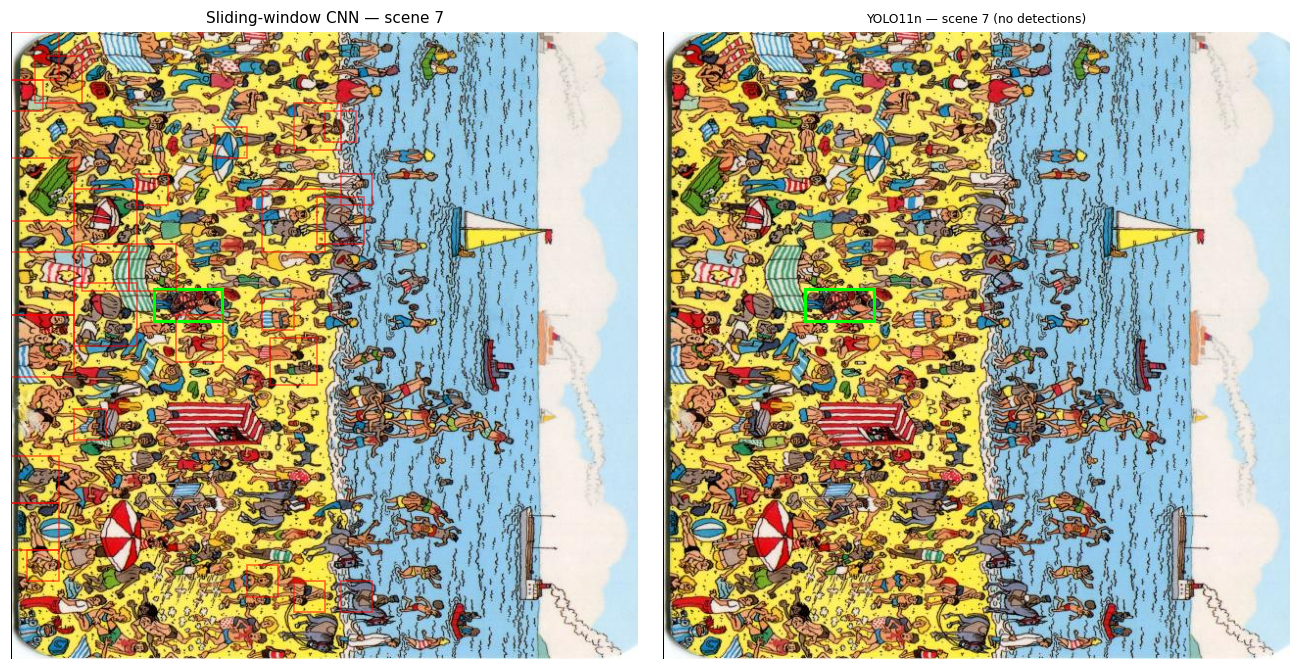

In [8]:
worst_fp_scene = sw_results.loc[sw_results["fp"].idxmax(), "scene_id"]
print(f"Scene with the most sliding-window false positives: {worst_fp_scene}")
show_both(worst_fp_scene)

## Practical comparison: size and speed

In [9]:
sw_params = sum(p.numel() for p in sw_model.parameters())
yolo_params = sum(p.numel() for p in yolo_model.model.parameters())

practical = pd.DataFrame([
    {"model": "Sliding-window CNN", "parameters": sw_params, "inference": "thousands of batched forward passes/image"},
    {"model": "YOLO11n", "parameters": yolo_params, "inference": "single forward pass/image"},
])
practical

,model,parameters,inference
0,Sliding-window CNN,98049,thousands of batched forward passes/image
1,YOLO11n,2590035,single forward pass/image


## Write-up: methodology, results, failure cases, what was learned

**Methodology.** Both detectors were trained and cross-validated on the same 19 hand-verified "hidden in
a crowd" scenes (notebook 01 filtered these out of a 65-scene source dataset that turned out to be
mostly unrelated portrait closeups), using the same scene-level 5-fold split (notebook 02) and the same
IoU-matched precision/recall/localization-error metrics (`src/eval/metrics.py`) for evaluation — never
accuracy, and never a framework's own self-reported metric for one model without also computing it for
the other. Both models' operating thresholds were chosen by sweeping on held-out validation data, not
picked arbitrarily (notebooks 03 and 04 each initially used an untuned default and caught it).

**Results.** See the comparison table and plot above (numbers are computed live from the saved CV
results, so they're the authoritative source — small run-to-run drift in the exact decimals is expected
from ordinary training non-determinism). Neither model achieves usable precision/recall in
cross-validated full-scene evaluation: the sliding-window CNN's best operating point still sits at
precision around 0.002-0.003 (essentially all detections are false positives), and the fine-tuned
YOLO11n gets **zero** true positives across all 19 scenes at every threshold tried. This is not the
result the project brief anticipated ("fine-tune a modern detector... for a real usable result") — but
it's the honest one, and it's directly traceable to a specific, diagnosed cause for each model, not an
unexplained low number.

**Failure cases.**
- *Sliding-window CNN*: fails by over-firing, not under-firing. It calls large fractions of every scene
  "Waldo" (hundreds of false positives per image even at its best threshold), because the training
  distribution (clean, centered, jittered crops) doesn't match the inference distribution (thousands of
  arbitrary, mostly off-target sliding-window crops). Hard-negative mining — the standard fix — made this
  *worse*, not better, because with only ~126 real positive patches, 172 mined negatives were enough to
  overwhelm what little positive signal existed.
- *YOLO11n*: fails by memorizing, not generalizing. Direct inspection of raw predictions (notebook 04)
  showed a near-perfect, high-confidence box on a *training* image and only low-confidence noise on
  *validation* images — classic overfitting from fine-tuning a multi-million-parameter pretrained network
  on 15-16 images. A frozen-backbone mitigation helped marginally (recall 0.00 → 0.25 on one fold) but
  didn't change the overall picture.
- Both failure modes point at the same root cause from a different angle: **19 scenes is below the data
  floor either approach needs here**, not a flaw in one architecture versus the other.

**What was learned** (mapped to the project's explicit learning objectives):
- *IoU, NMS, sliding windows*: implemented and used from scratch throughout (`src/eval/box_utils.py`,
  `src/models/sliding_window.py`) — not imported from a detection framework.
- *Why detection metrics differ from accuracy*: quantified directly in notebook 01 (the ~1:2345 window
  imbalance), and it's precisely why a near-zero-precision model can still look deceptively okay under
  the wrong metric, or why "0 mAP" needs investigating rather than accepting at face value (notebook 04's
  threshold sweep and raw-prediction check turned an apparently-broken result into a diagnosed one).
- *Scene-level splitting*: verified explicitly, more than once — on the raw Roboflow split (notebook 01),
  on our own k-fold assignment (notebook 02), and implicitly respected by exporting YOLO data per fold
  (notebook 04) — rather than assumed anywhere.
- *Sliding-window-to-YOLO conceptual bridge*: made concrete by literally building both on the same data
  and evaluation code, which is exactly what let us tell "different failure mode, same root cause" apart
  from "one model is better" — a distinction a less controlled comparison would have missed.
- *Small-object detection challenges in a low-data regime*: this notebook's central result. Extreme
  scale, heavy imbalance, and a dataset that shrank from 65 to 19 usable scenes after cleaning turned out
  to be a harder ceiling than augmentation, hard-negative mining, or transfer learning alone could
  overcome — the most honest and probably most useful finding of the whole project: **for this task, more
  clean data would matter more than a better architecture.**